# IC3392 gas minus stellar LOS velocity residuals across three runs

This notebook subtracts the stellar LOS velocity map from the gas LOS velocity maps for IC3392:

`delta V = V_gas - V_stars`

Positive residuals mean the gas is more redshifted than the stellar velocity field at the same spaxel. The main diagnostic maps use a fixed zero-centered color scale from `-20` to `+20 km/s`, so systematic offsets and residual velocity-gradient patterns are visually comparable across runs.

Runs:

- `old_v721_7000`: original `v3_v7.2.1` run, old CONFIG, fitting to 7000 A.
- `v768_7000`: `v3tk_v7.6.8_7000`, v7.6.8 code with old-style CONFIG, fitting to 7000 A.
- `v768_full`: original `v3tk_v7.6.8`, wider/new CONFIG, fitting to 9100 A.

Gas lines:

- `HB4861`
- `HA6562`
- `NII6583`
- `SII6716`


In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import TwoSlopeNorm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)

root = Path('.')
GALAXY = 'IC3392'
RESIDUAL_LIMIT = 20.0  # km/s; fixed visual cap requested for the residual maps

RUNS = {
    'old_v721_7000': {
        'label': 'v3_v7.2.1 old CONFIG to 7000',
        'plot_label': '7.2.1 old cfg 7000',
        'kin_path': root / 'v3_v7.2.1' / GALAXY / f'{GALAXY}_KIN_maps.fits',
        'gas_path': root / 'v3_v7.2.1' / GALAXY / f'{GALAXY}_gas_BIN_maps.fits',
        'config_path': root / 'v3_v7.2.1' / GALAXY / 'CONFIG',
    },
    'v768_7000': {
        'label': 'v3tk_v7.6.8_7000 old-style CONFIG to 7000',
        'plot_label': '7.6.8 old cfg 7000',
        'kin_path': root / 'v3tk_v7.6.8_7000' / GALAXY / f'{GALAXY}_kin_maps.fits',
        'gas_path': root / 'v3tk_v7.6.8_7000' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'config_path': root / 'v3tk_v7.6.8_7000' / GALAXY / 'CONFIG',
    },
    'v768_full': {
        'label': 'v3tk_v7.6.8 full/new CONFIG to 9100',
        'plot_label': '7.6.8 full cfg 9100',
        'kin_path': root / 'v3tk_v7.6.8' / GALAXY / f'{GALAXY}_kin_maps.fits',
        'gas_path': root / 'v3tk_v7.6.8' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'config_path': root / 'v3tk_v7.6.8' / GALAXY / 'CONFIG',
    },
}
RUN_ORDER = ['old_v721_7000', 'v768_7000', 'v768_full']
GAS_LINES = ['HB4861', 'HA6562', 'NII6583', 'SII6716']
GAS_VELOCITY_EXTENSIONS = [f'{line}_VEL' for line in GAS_LINES]

PAIR_COMPARISONS = [
    {
        'pair_key': 'version_proxy',
        'baseline': 'old_v721_7000',
        'compare': 'v768_7000',
        'label': 'v7.6.8_7000 minus v7.2.1',
    },
    {
        'pair_key': 'config_effect',
        'baseline': 'v768_7000',
        'compare': 'v768_full',
        'label': 'full v7.6.8 minus v7.6.8_7000',
    },
    {
        'pair_key': 'total_effect',
        'baseline': 'old_v721_7000',
        'compare': 'v768_full',
        'label': 'full v7.6.8 minus v7.2.1',
    },
]


def describe_path(path):
    if not path.exists():
        return {'exists': False, 'size_mb': np.nan, 'modified': ''}
    return {
        'exists': True,
        'size_mb': path.stat().st_size / 1024**2,
        'modified': datetime.fromtimestamp(path.stat().st_mtime).strftime('%Y-%m-%d %H:%M:%S'),
    }


file_rows = []
for run_key in RUN_ORDER:
    info = RUNS[run_key]
    for kind in ['kin_path', 'gas_path', 'config_path']:
        path = info[kind]
        status = describe_path(path)
        if not status['exists']:
            raise FileNotFoundError(f'Missing {run_key} {kind}: {path}')
    file_rows.append(
        {
            'run_key': run_key,
            'label': info['label'],
            'kin_path': str(info['kin_path']),
            'gas_path': str(info['gas_path']),
            'config_path': str(info['config_path']),
            'kin_modified': describe_path(info['kin_path'])['modified'],
        }
    )

print('All required KIN, GAS, and CONFIG files found.')
display(pd.DataFrame(file_rows))


All required KIN, GAS, and CONFIG files found.


,run_key,label,kin_path,gas_path,config_path,kin_modified
0,old_v721_7000,v3_v7.2.1 old CONFIG to 7000,v3_v7.2.1/IC3392/IC3392_KIN_maps.fits,v3_v7.2.1/IC3392/IC3392_gas_BIN_maps.fits,v3_v7.2.1/IC3392/CONFIG,2026-03-15 13:55:42
1,v768_7000,v3tk_v7.6.8_7000 old-style CONFIG to 7000,v3tk_v7.6.8_7000/IC3392/IC3392_kin_maps.fits,v3tk_v7.6.8_7000/IC3392/IC3392_gas_bin_maps.fits,v3tk_v7.6.8_7000/IC3392/CONFIG,2026-05-04 15:14:57
2,v768_full,v3tk_v7.6.8 full/new CONFIG to 9100,v3tk_v7.6.8/IC3392/IC3392_kin_maps.fits,v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps.fits,v3tk_v7.6.8/IC3392/CONFIG,2026-03-21 13:47:53


## Load velocity maps

The stellar velocity map is `KIN/V`. The gas velocity maps are `HB4861_VEL`, `HA6562_VEL`, `NII6583_VEL`, and `SII6716_VEL`. All maps are cropped only if a shape mismatch is detected; for the current IC3392 products they are already the same shape.

In [2]:
def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


def check_extensions(path, extensions):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        available = {hdu.name for hdu in hdul}
    missing = [ext for ext in extensions if ext not in available]
    if missing:
        raise KeyError(f'{path} missing extensions: {missing}')


def align_map_set(map_by_key, label=None):
    shapes = {key: arr.shape for key, arr in map_by_key.items()}
    unique_shapes = set(shapes.values())
    if len(unique_shapes) == 1:
        return map_by_key

    ndim = {len(shape) for shape in unique_shapes}
    if len(ndim) != 1:
        raise ValueError(f'{label or "map"}: cannot align maps with dimensions {shapes}')

    common_shape = tuple(min(shape[axis] for shape in unique_shapes) for axis in range(next(iter(ndim))))
    slices = tuple(slice(0, n) for n in common_shape)
    print(f'Warning: {label or "map"} shape mismatch {shapes}; using common crop {common_shape}.')
    return {key: arr[slices] for key, arr in map_by_key.items()}


for run_key in RUN_ORDER:
    check_extensions(RUNS[run_key]['kin_path'], ['V'])
    check_extensions(RUNS[run_key]['gas_path'], GAS_VELOCITY_EXTENSIONS)

stellar_v = align_map_set(
    {run_key: read_map(RUNS[run_key]['kin_path'], 'V') for run_key in RUN_ORDER},
    'stellar KIN_V',
)

gas_v = {
    line: align_map_set(
        {run_key: read_map(RUNS[run_key]['gas_path'], f'{line}_VEL') for run_key in RUN_ORDER},
        f'gas {line}_VEL',
    )
    for line in GAS_LINES
}

print('Loaded velocity maps:')
for run_key in RUN_ORDER:
    print(f"  {run_key}: stellar {stellar_v[run_key].shape}; " + ', '.join(f'{line} {gas_v[line][run_key].shape}' for line in GAS_LINES))


Loaded velocity maps:
  old_v721_7000: stellar (438, 437); HB4861 (438, 437), HA6562 (438, 437), NII6583 (438, 437), SII6716 (438, 437)
  v768_7000: stellar (438, 437); HB4861 (438, 437), HA6562 (438, 437), NII6583 (438, 437), SII6716 (438, 437)
  v768_full: stellar (438, 437); HB4861 (438, 437), HA6562 (438, 437), NII6583 (438, 437), SII6716 (438, 437)


## Build gas minus stellar residual maps

The residual maps below use `delta V = V_gas - V_stars`. This sign convention makes a positive value mean that the gas LOS velocity is more redshifted than the stellar LOS velocity.

In [3]:
def finite_values(arrays):
    chunks = []
    for arr in arrays:
        vals = np.asarray(arr)[np.isfinite(arr)]
        if vals.size > 0:
            chunks.append(vals.ravel())
    if not chunks:
        return np.array([], dtype=float)
    return np.concatenate(chunks)


def robust_symmetric_limit(arr, percentile=98, fallback=1.0):
    vals = np.abs(np.asarray(arr)[np.isfinite(arr)])
    if vals.size == 0:
        return float(fallback)
    limit = np.nanpercentile(vals, percentile)
    if not np.isfinite(limit) or limit == 0:
        limit = np.nanmax(vals)
    if not np.isfinite(limit) or limit == 0:
        limit = fallback
    return float(limit)


def residual_stats(arr):
    vals = arr[np.isfinite(arr)]
    if vals.size == 0:
        return {
            'n_valid': 0,
            'median_delta_v': np.nan,
            'mean_delta_v': np.nan,
            'std_delta_v': np.nan,
            'median_abs_delta_v': np.nan,
            'p16_delta_v': np.nan,
            'p84_delta_v': np.nan,
            'rms_delta_v': np.nan,
            'frac_abs_gt_20': np.nan,
        }
    return {
        'n_valid': int(vals.size),
        'median_delta_v': float(np.nanmedian(vals)),
        'mean_delta_v': float(np.nanmean(vals)),
        'std_delta_v': float(np.nanstd(vals)),
        'median_abs_delta_v': float(np.nanmedian(np.abs(vals))),
        'p16_delta_v': float(np.nanpercentile(vals, 16)),
        'p84_delta_v': float(np.nanpercentile(vals, 84)),
        'rms_delta_v': float(np.sqrt(np.nanmean(vals**2))),
        'frac_abs_gt_20': float(np.mean(np.abs(vals) > RESIDUAL_LIMIT)),
    }


residual_v = {
    line: {
        run_key: gas_v[line][run_key] - stellar_v[run_key]
        for run_key in RUN_ORDER
    }
    for line in GAS_LINES
}

summary_rows = []
for line in GAS_LINES:
    for run_key in RUN_ORDER:
        row = {
            'line': line,
            'run_key': run_key,
            'run_label': RUNS[run_key]['plot_label'],
            'definition': f'{line}_VEL - KIN_V',
        }
        row.update(residual_stats(residual_v[line][run_key]))
        summary_rows.append(row)

residual_summary = pd.DataFrame(summary_rows)
display(residual_summary)


,line,run_key,run_label,definition,n_valid,median_delta_v,mean_delta_v,std_delta_v,median_abs_delta_v,p16_delta_v,p84_delta_v,rms_delta_v,frac_abs_gt_20
0,HB4861,old_v721_7000,7.2.1 old cfg 7000,HB4861_VEL - KIN_V,73168,5.560319,11.804681,38.031666,10.724887,-6.664915,38.307229,39.821578,0.324923
1,HB4861,v768_7000,7.6.8 old cfg 7000,HB4861_VEL - KIN_V,72336,5.738399,10.571801,33.557451,9.592128,-6.415470,33.547299,35.183313,0.282736
2,HB4861,v768_full,7.6.8 full cfg 9100,HB4861_VEL - KIN_V,94543,1.078780,10.179754,37.289292,16.460840,-15.509287,44.100438,38.653832,0.436373
3,HA6562,old_v721_7000,7.2.1 old cfg 7000,HA6562_VEL - KIN_V,73168,5.560319,11.804681,38.031666,10.724887,-6.664915,38.307229,39.821578,0.324923
4,HA6562,v768_7000,7.6.8 old cfg 7000,HA6562_VEL - KIN_V,72336,5.738399,10.571801,33.557451,9.592128,-6.415470,33.547299,35.183313,0.282736
5,HA6562,v768_full,7.6.8 full cfg 9100,HA6562_VEL - KIN_V,94543,1.078780,10.179754,37.289292,16.460840,-15.509287,44.100438,38.653832,0.436373
6,NII6583,old_v721_7000,7.2.1 old cfg 7000,NII6583_VEL - KIN_V,73168,4.313788,5.019071,17.054241,10.357746,-10.385697,20.331913,17.777464,0.230251
7,NII6583,v768_7000,7.6.8 old cfg 7000,NII6583_VEL - KIN_V,72336,3.896998,4.583319,16.589638,10.059925,-10.307124,19.659846,17.211127,0.221674
8,NII6583,v768_full,7.6.8 full cfg 9100,NII6583_VEL - KIN_V,94543,-10.397826,-14.092834,25.432316,13.881534,-30.727041,5.871789,29.075947,0.326793
9,SII6716,old_v721_7000,7.2.1 old cfg 7000,SII6716_VEL - KIN_V,73168,4.313788,5.019071,17.054241,10.357746,-10.385697,20.331913,17.777464,0.230251


## Residual maps for each run

The colorbar is fixed at `-20` to `+20 km/s` and centered at zero for every panel. Values outside that range are saturated intentionally so the low-level residual pattern is easy to compare.

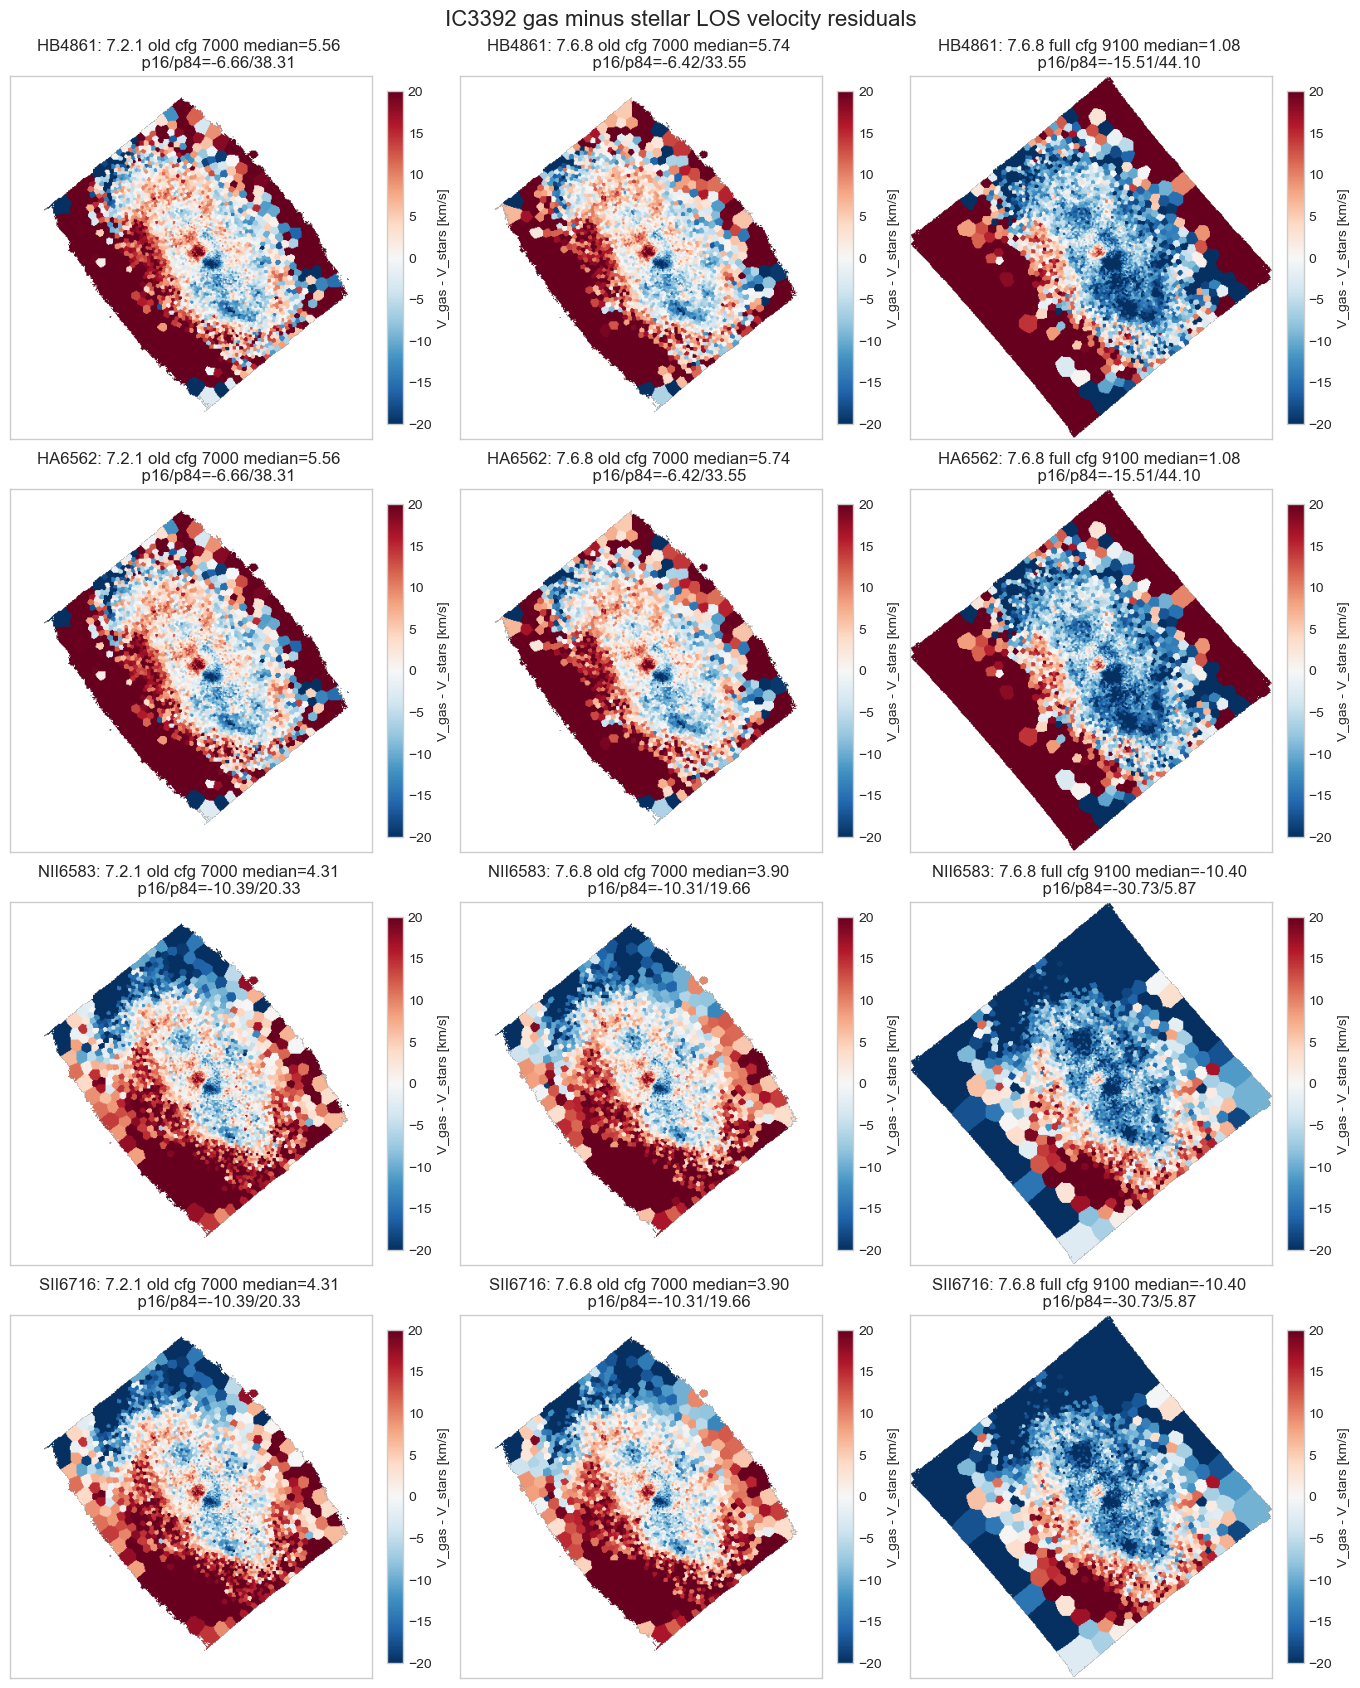

In [4]:
RESIDUAL_CMAP = 'RdBu_r'
RESIDUAL_NORM = TwoSlopeNorm(vmin=-RESIDUAL_LIMIT, vcenter=0.0, vmax=RESIDUAL_LIMIT)


def plot_residual_maps_by_run():
    fig, axes = plt.subplots(
        len(GAS_LINES),
        len(RUN_ORDER),
        figsize=(4.5 * len(RUN_ORDER), 4.2 * len(GAS_LINES)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('IC3392 gas minus stellar LOS velocity residuals', fontsize=16)

    for row, line in enumerate(GAS_LINES):
        for col, run_key in enumerate(RUN_ORDER):
            residual = residual_v[line][run_key]
            vals = residual[np.isfinite(residual)]
            median = np.nanmedian(vals) if vals.size else np.nan
            p16 = np.nanpercentile(vals, 16) if vals.size else np.nan
            p84 = np.nanpercentile(vals, 84) if vals.size else np.nan

            ax = axes[row, col]
            im = ax.imshow(residual, origin='lower', cmap=RESIDUAL_CMAP, norm=RESIDUAL_NORM)
            ax.set_title(f"""{line}: {RUNS[run_key]['plot_label']} median={median:.2f} 
            p16/p84={p16:.2f}/{p84:.2f}""")
            ax.set_xticks([])
            ax.set_yticks([])
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('V_gas - V_stars [km/s]')

    plt.show()


plot_residual_maps_by_run()


## Same residuals with per-line rows and shared contours

This view repeats the same maps but overlays the zero-residual contour. If the residuals are mostly a systematic offset, most of a panel will sit on one color side. If a residual velocity gradient remains, the zero contour should cut through the field and separate red/blue spatial structure.

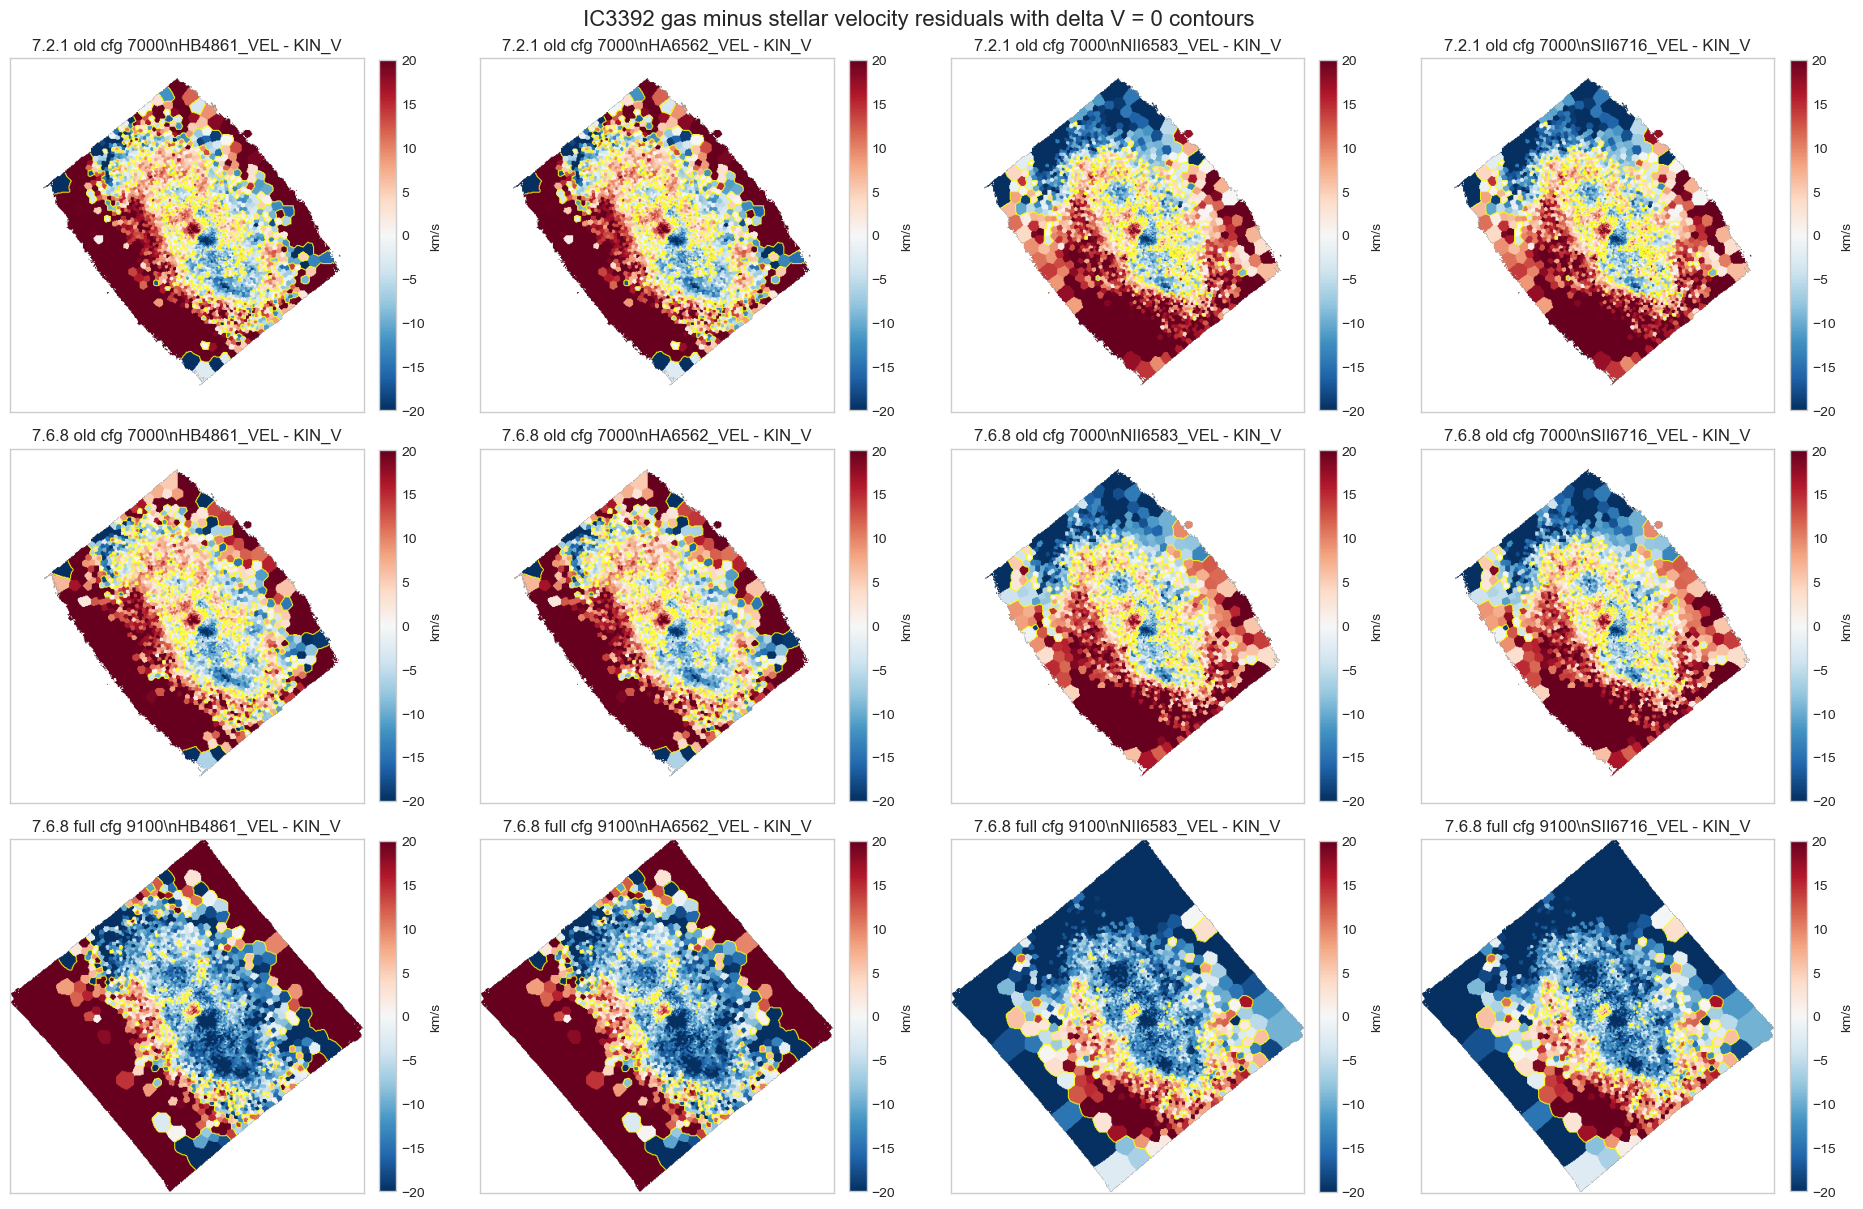

In [5]:
def plot_residual_maps_with_zero_contours():
    fig, axes = plt.subplots(
        len(RUN_ORDER),
        len(GAS_LINES),
        figsize=(4.7 * len(GAS_LINES), 4.0 * len(RUN_ORDER)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('IC3392 gas minus stellar velocity residuals with delta V = 0 contours', fontsize=16)

    for row, run_key in enumerate(RUN_ORDER):
        for col, line in enumerate(GAS_LINES):
            residual = residual_v[line][run_key]
            ax = axes[row, col]
            im = ax.imshow(residual, origin='lower', cmap=RESIDUAL_CMAP, norm=RESIDUAL_NORM)
            if np.nanmin(residual) < 0 < np.nanmax(residual):
                ax.contour(residual, levels=[0], colors='yellow', linewidths=0.8, alpha=0.85, origin='lower')
            ax.set_title(f"{RUNS[run_key]['plot_label']}\\n{line}_VEL - KIN_V")
            ax.set_xticks([])
            ax.set_yticks([])
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('km/s')

    plt.show()


plot_residual_maps_with_zero_contours()


## Difference between residual maps across runs

These panels ask whether the gas-minus-stellar residual pattern itself changes between runs. The quantity is:

`(V_gas - V_stars)_compare - (V_gas - V_stars)_baseline`

The same `[-20, +20] km/s` visual cap is used.

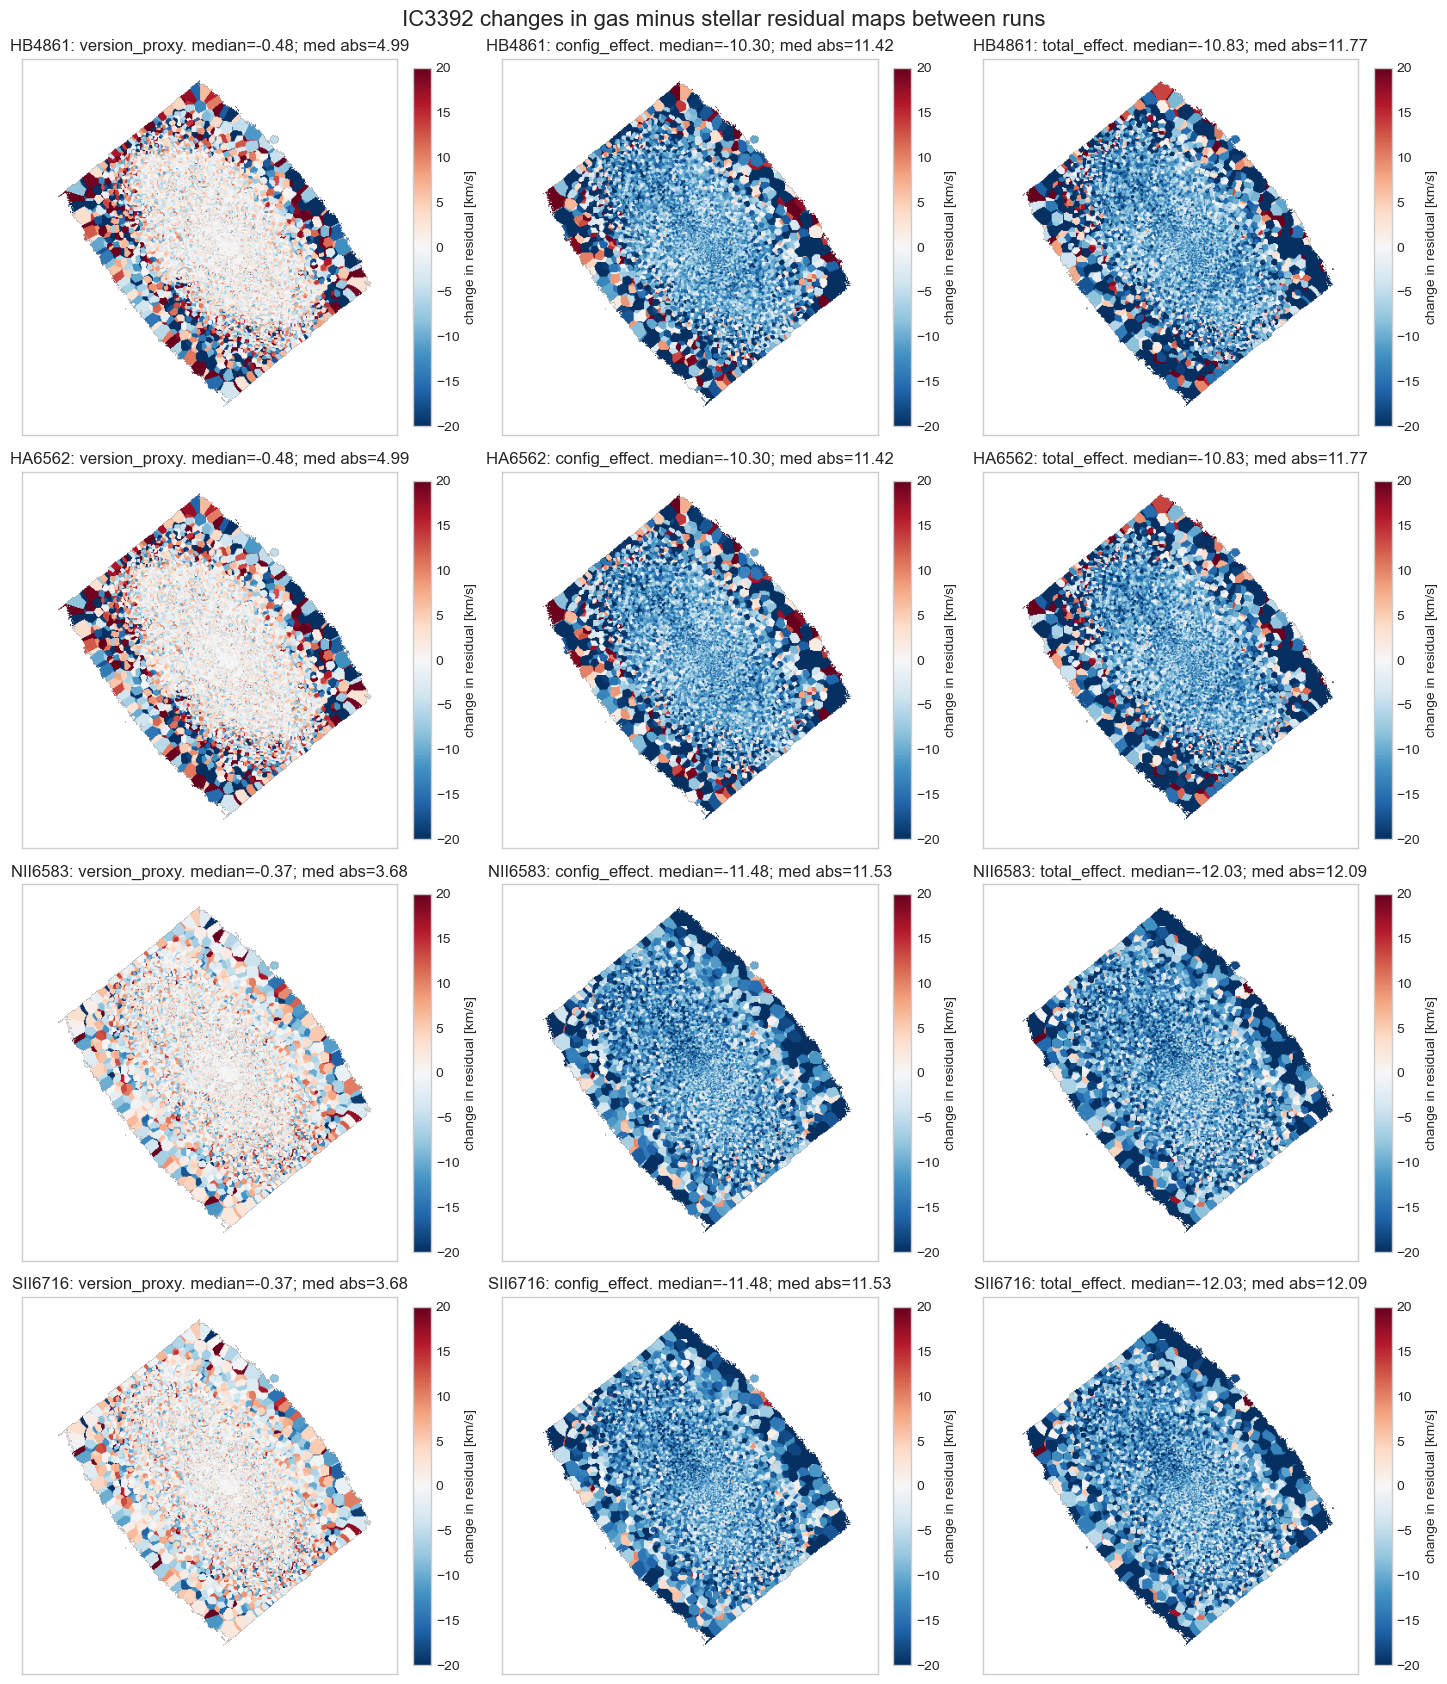

,line,pair_key,definition,n_valid,median_change,median_abs_change,rms_change
0,HB4861,version_proxy,(HB4861 - stars) v768_7000 - old_v721_7000,72335,-0.482990,4.994371,27.742219
1,HB4861,config_effect,(HB4861 - stars) v768_full - v768_7000,72080,-10.296938,11.420006,30.649338
2,HB4861,total_effect,(HB4861 - stars) v768_full - old_v721_7000,72910,-10.834616,11.770436,37.899362
3,HA6562,version_proxy,(HA6562 - stars) v768_7000 - old_v721_7000,72335,-0.482990,4.994371,27.742219
4,HA6562,config_effect,(HA6562 - stars) v768_full - v768_7000,72080,-10.296938,11.420006,30.649338
5,HA6562,total_effect,(HA6562 - stars) v768_full - old_v721_7000,72910,-10.834616,11.770436,37.899362
6,NII6583,version_proxy,(NII6583 - stars) v768_7000 - old_v721_7000,72335,-0.370768,3.680019,6.771872
7,NII6583,config_effect,(NII6583 - stars) v768_full - v768_7000,72080,-11.484338,11.531857,15.956251
8,NII6583,total_effect,(NII6583 - stars) v768_full - old_v721_7000,72910,-12.034475,12.085088,16.913052
9,SII6716,version_proxy,(SII6716 - stars) v768_7000 - old_v721_7000,72335,-0.370768,3.680019,6.771872


In [6]:
def plot_residual_map_differences():
    fig, axes = plt.subplots(
        len(GAS_LINES),
        len(PAIR_COMPARISONS),
        figsize=(4.8 * len(PAIR_COMPARISONS), 4.2 * len(GAS_LINES)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('IC3392 changes in gas minus stellar residual maps between runs', fontsize=16)

    rows = []
    for row, line in enumerate(GAS_LINES):
        for col, pair in enumerate(PAIR_COMPARISONS):
            diff = residual_v[line][pair['compare']] - residual_v[line][pair['baseline']]
            vals = diff[np.isfinite(diff)]
            median = np.nanmedian(vals) if vals.size else np.nan
            med_abs = np.nanmedian(np.abs(vals)) if vals.size else np.nan
            rows.append(
                {
                    'line': line,
                    'pair_key': pair['pair_key'],
                    'definition': f"({line} - stars) {pair['compare']} - {pair['baseline']}",
                    'n_valid': int(vals.size),
                    'median_change': float(median),
                    'median_abs_change': float(med_abs),
                    'rms_change': float(np.sqrt(np.nanmean(vals**2))) if vals.size else np.nan,
                }
            )

            ax = axes[row, col]
            im = ax.imshow(diff, origin='lower', cmap=RESIDUAL_CMAP, norm=RESIDUAL_NORM)
            ax.set_title(f"{line}: {pair['pair_key']}. median={median:.2f}; med abs={med_abs:.2f}")
            ax.set_xticks([])
            ax.set_yticks([])
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('change in residual [km/s]')

    plt.show()
    return pd.DataFrame(rows)


residual_difference_summary = plot_residual_map_differences()
display(residual_difference_summary)


## Simple residual-gradient diagnostic

This helper fits a plane to each residual map after centering pixel coordinates. It is only a compact diagnostic for whether a residual map still contains a large-scale gradient; the maps above remain the main check.

In [7]:
def fit_residual_plane(arr):
    yy, xx = np.indices(arr.shape)
    mask = np.isfinite(arr)
    if mask.sum() < 3:
        return {
            'plane_offset_at_center': np.nan,
            'slope_x_kms_per_pix': np.nan,
            'slope_y_kms_per_pix': np.nan,
            'plane_peak_to_peak_kms': np.nan,
            'plane_rms_kms': np.nan,
        }

    x = xx[mask].astype(float)
    y = yy[mask].astype(float)
    z = arr[mask].astype(float)
    x0 = 0.5 * (arr.shape[1] - 1)
    y0 = 0.5 * (arr.shape[0] - 1)
    design = np.column_stack([np.ones_like(x), x - x0, y - y0])
    offset, slope_x, slope_y = np.linalg.lstsq(design, z, rcond=None)[0]

    corners = np.array(
        [
            [1.0, -x0, -y0],
            [1.0, arr.shape[1] - 1 - x0, -y0],
            [1.0, -x0, arr.shape[0] - 1 - y0],
            [1.0, arr.shape[1] - 1 - x0, arr.shape[0] - 1 - y0],
        ]
    )
    corner_vals = corners @ np.array([offset, slope_x, slope_y])
    plane_vals = design @ np.array([offset, slope_x, slope_y])
    return {
        'plane_offset_at_center': float(offset),
        'slope_x_kms_per_pix': float(slope_x),
        'slope_y_kms_per_pix': float(slope_y),
        'plane_peak_to_peak_kms': float(np.nanmax(corner_vals) - np.nanmin(corner_vals)),
        'plane_rms_kms': float(np.sqrt(np.nanmean((plane_vals - np.nanmean(plane_vals))**2))),
    }


gradient_rows = []
for line in GAS_LINES:
    for run_key in RUN_ORDER:
        row = {
            'line': line,
            'run_key': run_key,
            'run_label': RUNS[run_key]['plot_label'],
        }
        row.update(fit_residual_plane(residual_v[line][run_key]))
        gradient_rows.append(row)

residual_gradient_summary = pd.DataFrame(gradient_rows)
display(residual_gradient_summary)


,line,run_key,run_label,plane_offset_at_center,slope_x_kms_per_pix,slope_y_kms_per_pix,plane_peak_to_peak_kms,plane_rms_kms
0,HB4861,old_v721_7000,7.2.1 old cfg 7000,12.151932,0.024146,-0.078687,44.913971,6.986831
1,HB4861,v768_7000,7.6.8 old cfg 7000,11.148210,-0.008492,-0.074796,36.388206,5.862680
2,HB4861,v768_full,7.6.8 full cfg 9100,10.201788,-0.061413,-0.063822,54.666336,7.823548
3,HA6562,old_v721_7000,7.2.1 old cfg 7000,12.151932,0.024146,-0.078687,44.913971,6.986831
4,HA6562,v768_7000,7.6.8 old cfg 7000,11.148210,-0.008492,-0.074796,36.388206,5.862680
5,HA6562,v768_full,7.6.8 full cfg 9100,10.201788,-0.061413,-0.063822,54.666336,7.823548
6,NII6583,old_v721_7000,7.2.1 old cfg 7000,5.978403,0.009569,-0.152131,70.653299,12.412045
7,NII6583,v768_7000,7.6.8 old cfg 7000,5.578102,0.006670,-0.153330,69.913441,12.403424
8,NII6583,v768_full,7.6.8 full cfg 9100,-13.929876,0.071110,-0.158073,100.081919,15.435242
9,SII6716,old_v721_7000,7.2.1 old cfg 7000,5.978403,0.009569,-0.152131,70.653299,12.412045


## Optional save

Uncomment these lines if you want CSV summaries for notes or a report.

In [8]:
# residual_summary.to_csv('IC3392_gas_minus_stellar_velocity_3runs_summary.csv', index=False)
# residual_difference_summary.to_csv('IC3392_gas_minus_stellar_velocity_3runs_difference_summary.csv', index=False)
# residual_gradient_summary.to_csv('IC3392_gas_minus_stellar_velocity_3runs_gradient_summary.csv', index=False)
# print('Saved gas-minus-stellar velocity residual summaries.')
